# What actually wins on the Kaggriculture ladder, read from the replays

Most reads on this competition explain the crop economics or hand you a baseline agent. This one recomputes
the meta in front of you from the raw episode replays, so every number below comes from parsing the actual
720 turn games, not from the game manual. Each episode is one ranked match between two submitted agents. From
its replay I read what each side actually did, tag each side by its agent name, and read the winner from the
final profit. Aggregate a day of ladder games and you get the real question answered: not which crop pays
most on paper, but what the farms that actually win do differently from the farms that lose.

Fork it, point it at another day, and it recomputes. Every archetype, win rate, and strategy number is
parsed live from the logs, with no pasted figures and no leaderboard claim.

In [1]:
import os, glob, json, re, time, random
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
INK = "#1b2a4a"; ACC = "#c1440e"; ACC2 = "#1f6f8b"; GD = "#c29a22"; MUT = "#8a94a6"

def find_dir(must_digit_json=True):
    for d in sorted(glob.glob("/kaggle/input/*")) + ["D:/kaggle/scratchpad/kagg"]:
        js = [p for p in glob.glob(os.path.join(d, "*.json")) if os.path.basename(p)[:-5].isdigit()]
        if not js:
            js = [p for p in glob.glob(os.path.join(d, "**", "*.json"), recursive=True)
                  if os.path.basename(p)[:-5].isdigit()]
        if js:
            return os.path.dirname(js[0])
    return None
def find_one(name):
    for p in glob.glob(f"/kaggle/input/**/{name}", recursive=True) + glob.glob(f"D:/kaggle/**/{name}", recursive=True):
        return p
    return None

epdir = find_dir()
assert epdir is not None, "no numbered replay json folder found under /kaggle/input"
files = sorted(p for p in glob.glob(os.path.join(epdir, "*.json")) if os.path.basename(p)[:-5].isdigit())
CAP = 300                       # replays are ~25MB each; a seeded sample of the day keeps the run tractable
if len(files) > CAP:
    random.seed(0); files = sorted(random.sample(files, CAP))
_m = re.search(r"(\d{4}-\d{2}-\d{2})", epdir or ""); DAY = _m.group(1) if _m else "unknown"
print("replay dir:", epdir, "| day:", DAY, "| games to parse:", len(files))

replay dir: /kaggle/input/datasets/organizations/kaggle/kaggriculture-episodes-2026-08-01 | day: 2026-08-01 | games to parse: 300


In [2]:
# each replay: rewards = [profit0, profit1] (winner = higher), info.TeamNames = the two agents,
# steps[i][seat].action = {farmer:[move], hands:[[op,...]], market:[[op,...]]} for 720 turns
CROP_KEYS = ["STRAWBERRY", "WHEAT", "MELON", "CARROT"]
def parse_replay(path):
    try:
        d = json.load(open(path, encoding="utf-8"))
    except Exception:
        return None
    rew = d.get("rewards") or []
    if len(rew) != 2 or rew[0] is None or rew[1] is None or rew[0] == rew[1]:
        return None                                   # unfinished or tied games are dropped
    names = (d.get("info") or {}).get("TeamNames") or ["?", "?"]
    winner = 0 if rew[0] > rew[1] else 1
    F = [dict(crops=Counter(), plant=0, sell=0, hire=0, buy_animal=0, buy_land=0, fert=0, harvest=0, water=0)
         for _ in range(2)]
    for st in d.get("steps", []):
        if not isinstance(st, list):
            continue
        for seat in range(min(2, len(st))):
            a = (st[seat] or {}).get("action") or {}
            for h in a.get("hands") or []:
                if not h:
                    continue
                op = h[0]
                if op == "PLANT":
                    F[seat]["plant"] += 1
                    if len(h) > 1: F[seat]["crops"][h[1]] += 1
                elif op == "COLLECT_FERTILIZER": F[seat]["fert"] += 1
                elif op == "HARVEST": F[seat]["harvest"] += 1
                elif op == "WATER": F[seat]["water"] += 1
            for mk in a.get("market") or []:
                if not mk:
                    continue
                op = mk[0]
                if op == "SELL": F[seat]["sell"] += 1
                elif op == "HIRE": F[seat]["hire"] += 1
                elif op == "BUY_ANIMAL": F[seat]["buy_animal"] += 1
                elif op == "BUY_LAND": F[seat]["buy_land"] += 1
    rows = []
    for seat in range(2):
        f = F[seat]
        rows.append(dict(agent=str(names[seat])[:28], win=int(seat == winner), score=float(rew[seat]),
                         top_crop=(f["crops"].most_common(1)[0][0] if f["crops"] else "none"),
                         plant=f["plant"], sell=f["sell"], hire=f["hire"], buy_animal=f["buy_animal"],
                         buy_land=f["buy_land"], fert=f["fert"], harvest=f["harvest"]))
    return rows

t0 = time.time(); rows = []
for k, p in enumerate(files, 1):
    r = parse_replay(p)
    if r: rows.extend(r)
    if k % 50 == 0:
        print(f"  {k}/{len(files)} replays, {len(rows)//2} decisive, {round(time.time()-t0)}s", flush=True)
sides = pd.DataFrame(rows)
games = len(sides) // 2
print(f"parsed {games} decisive games ({len(sides)} sides) in {round(time.time()-t0)}s")
print("distinct agents seen:", sides["agent"].nunique())

  50/300 replays, 50 decisive, 26s
  100/300 replays, 98 decisive, 51s
  150/300 replays, 147 decisive, 77s
  200/300 replays, 195 decisive, 102s
  250/300 replays, 242 decisive, 127s
  300/300 replays, 290 decisive, 152s
parsed 290 decisive games (580 sides) in 152s
distinct agents seen: 75


## 1. The agent tier list

Every game has two sides, each an agent. Here is each agent's win rate across all its games, with a Wilson
interval so you can see which leads are real and which are small sample noise. This is the ladder as the
replays actually played out, not the public leaderboard rating.

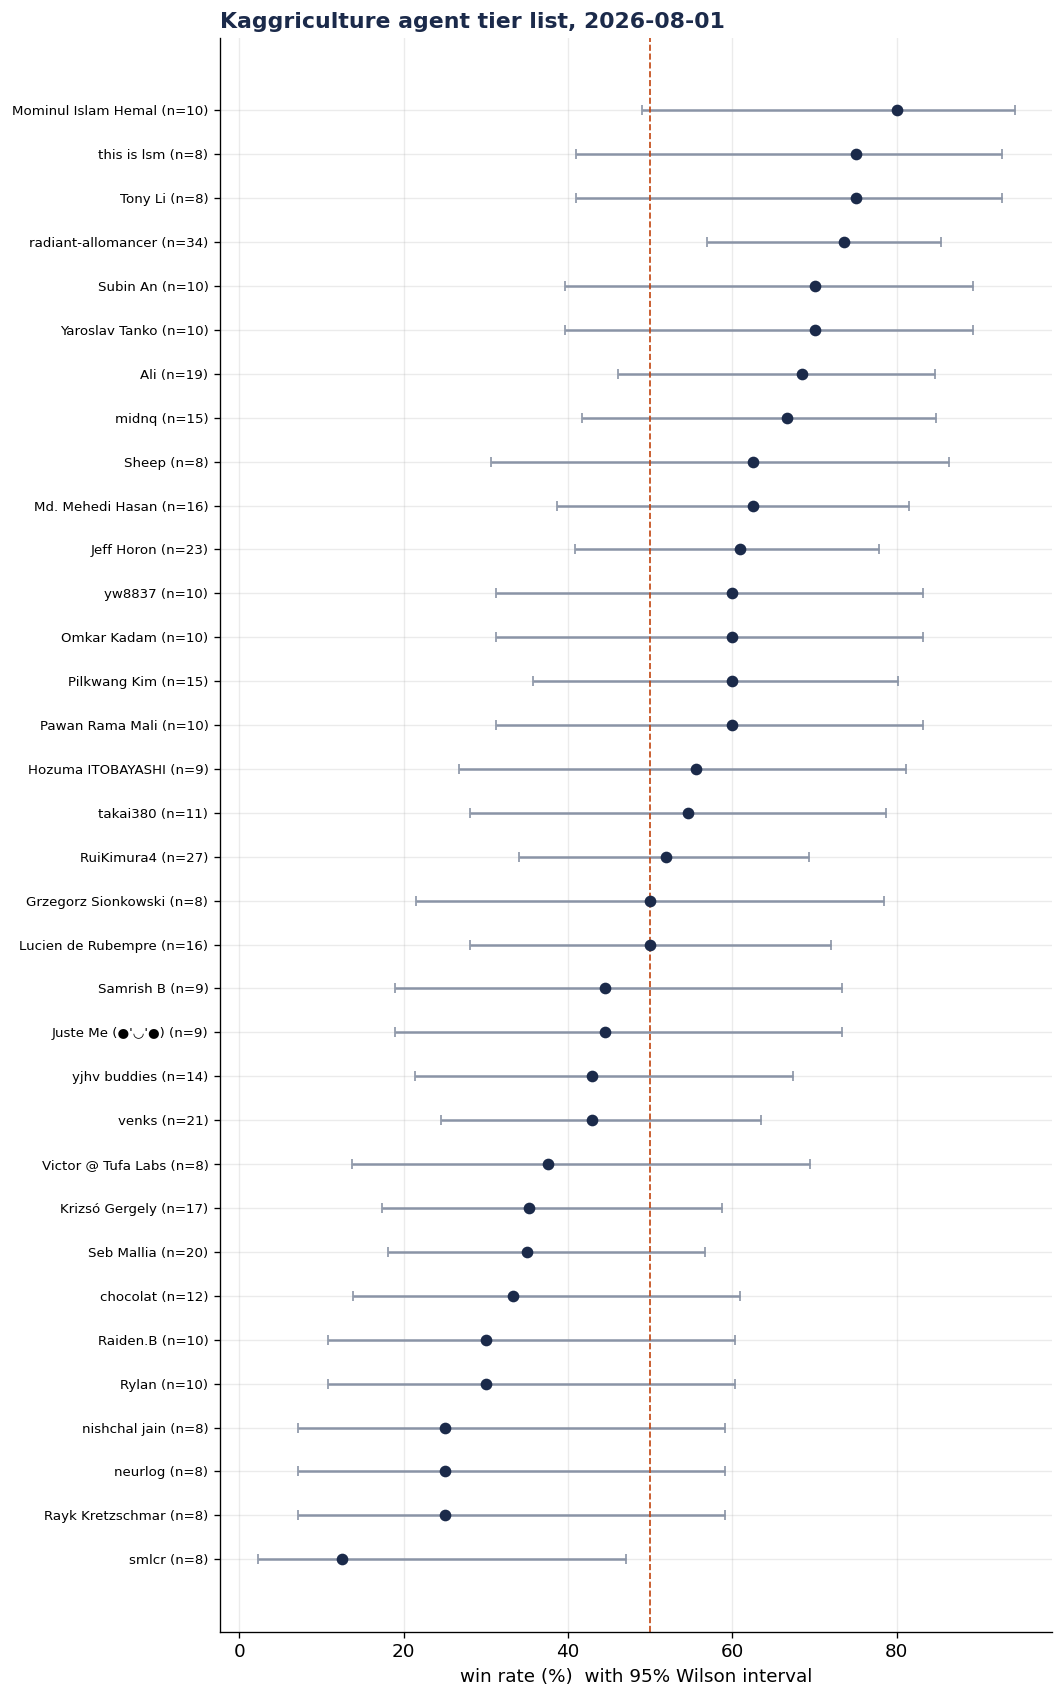

              agent  games  winrate    lo    hi  avg_score
Mominul Islam Hemal     10    0.800 0.490 0.943 130327.600
            Tony Li      8    0.750 0.409 0.929 115535.750
        this is lsm      8    0.750 0.409 0.929 105802.875
 radiant-allomancer     34    0.735 0.569 0.854 120480.235
     Yaroslav Tanko     10    0.700 0.397 0.892 122408.700
           Subin An     10    0.700 0.397 0.892 118893.100
                Ali     19    0.684 0.460 0.846 126160.684
              midnq     15    0.667 0.417 0.848 120536.000
   Md. Mehedi Hasan     16    0.625 0.386 0.815 102871.750
              Sheep      8    0.625 0.306 0.863 115961.750
         Jeff Horon     23    0.609 0.408 0.778 115826.000
       Pilkwang Kim     15    0.600 0.357 0.802 115376.333
             yw8837     10    0.600 0.313 0.832 109554.100
    Pawan Rama Mali     10    0.600 0.313 0.832 113998.200
        Omkar Kadam     10    0.600 0.313 0.832 108144.000
  Hozuma ITOBAYASHI      9    0.556 0.267 0.811 112560.3

In [3]:
def wilson(w, n, z=1.96):
    if n == 0: return (0, 0, 0)
    p = w / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d; h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return p, c-h, c+h
g = sides.groupby("agent")
rec = []
for a, sub in g:
    w, n = int(sub["win"].sum()), len(sub)
    p, lo, hi = wilson(w, n)
    rec.append(dict(agent=a, games=n, winrate=p, lo=lo, hi=hi, avg_score=sub["score"].mean()))
T = pd.DataFrame(rec)
T = T[T["games"] >= max(8, T["games"].quantile(0.5))].sort_values("winrate")
fig, ax = plt.subplots(figsize=(9, max(4, 0.42*len(T))))
ax.errorbar(T["winrate"]*100, range(len(T)), xerr=[(T.winrate-T.lo)*100, (T.hi-T.winrate)*100],
            fmt="o", color=INK, ecolor=MUT, capsize=3)
ax.axvline(50, color=ACC, lw=1, ls="--")
ax.set_yticks(range(len(T)), [f"{a[:24]} (n={n})" for a, n in zip(T.agent, T.games)], fontsize=8)
ax.set_xlabel("win rate (%)  with 95% Wilson interval")
ax.set_title(f"Kaggriculture agent tier list, {DAY}", color=INK, loc="left", fontweight="bold")
plt.tight_layout(); plt.show()
print(T.sort_values("winrate", ascending=False).round(3).to_string(index=False))

## 2. What the winning farms actually do

This is the cell worth reading. For every side we counted the real moves: how much it planted, sold on the
market, hired farm hands, bought animals and land, and collected fertilizer over the season. Here are those
counts averaged for the winning side versus the losing side of the same games. The gaps are what winners
tend to do more or less of, separate from what the manual says pays. Read them as description, not proof
that any one action causes the win; both sides play the same 720 turns, so the counts are comparable.

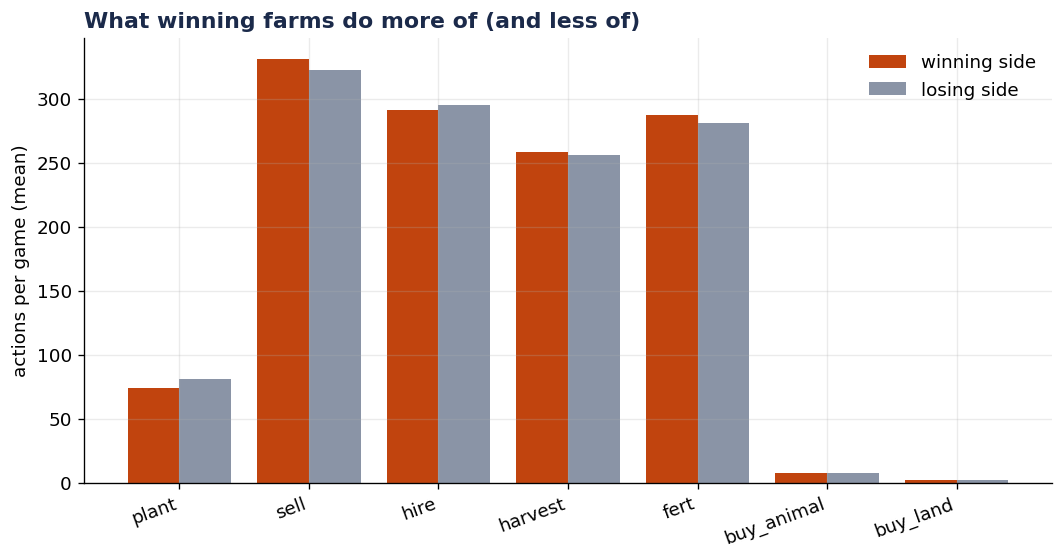

            winning  losing  ratio
plant          74.2    81.0    0.9
sell          331.1   322.3    1.0
hire          290.9   294.7    1.0
harvest       258.1   256.1    1.0
fert          287.2   280.8    1.0
buy_animal      7.6     8.0    1.0
buy_land        2.5     2.8    0.9

mean final profit: winners 118420 | losers 110265


In [4]:
feat = ["plant", "sell", "hire", "harvest", "fert", "buy_animal", "buy_land"]
win_mean = sides[sides.win == 1][feat].mean()
los_mean = sides[sides.win == 0][feat].mean()
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(feat)); w = 0.4
ax.bar(x - w/2, win_mean.values, w, label="winning side", color=ACC)
ax.bar(x + w/2, los_mean.values, w, label="losing side", color=MUT)
ax.set_xticks(x, feat, rotation=20, ha="right")
ax.set_ylabel("actions per game (mean)")
ax.set_title("What winning farms do more of (and less of)", color=INK, loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
cmp = pd.DataFrame({"winning": win_mean, "losing": los_mean})
cmp["ratio"] = (cmp["winning"] / cmp["losing"].replace(0, np.nan)).round(2)
print(cmp.round(1).to_string())
print("\nmean final profit: winners", round(sides[sides.win==1].score.mean()),
      "| losers", round(sides[sides.win==0].score.mean()))

## 3. Which crop the winners lean on

Each side has a most planted crop. This is how often each crop is the primary crop of a winning side versus
a losing side, which tells you what the field currently rewards without you having to submit an agent to find
out.

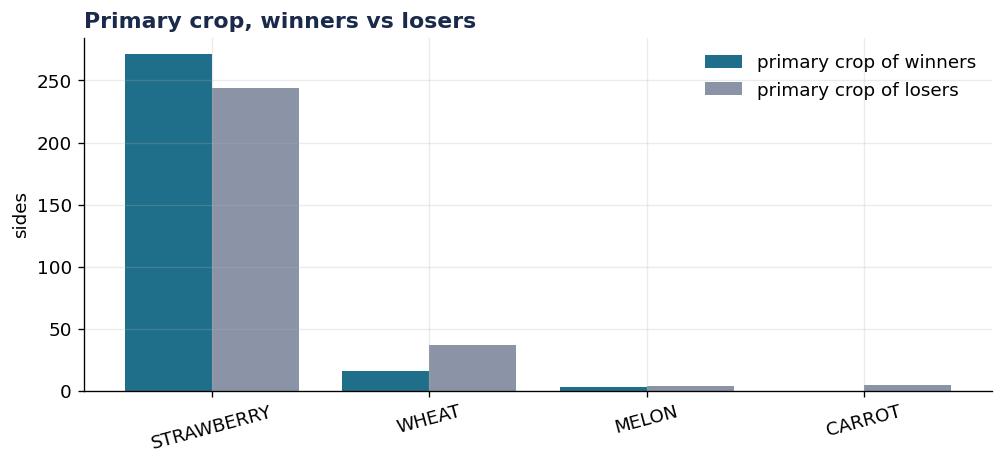

win rate when a crop is the primary crop:
  STRAWBERRY   53%  (n=515)
  WHEAT        30%  (n=53)
  MELON        43%  (n=7)
  CARROT       0%  (n=5)


In [5]:
cw = sides[sides.win == 1]["top_crop"].value_counts()
cl = sides[sides.win == 0]["top_crop"].value_counts()
order = [c for c in (CROP_KEYS + ["none"]) if c in set(cw.index) | set(cl.index)]
wv = [cw.get(c, 0) for c in order]; lv = [cl.get(c, 0) for c in order]
fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(order)); w = 0.4
ax.bar(x - w/2, wv, w, label="primary crop of winners", color=ACC2)
ax.bar(x + w/2, lv, w, label="primary crop of losers", color=MUT)
ax.set_xticks(x, order, rotation=15); ax.set_ylabel("sides")
ax.set_title("Primary crop, winners vs losers", color=INK, loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
wr = {c: (cw.get(c,0) / (cw.get(c,0)+cl.get(c,0)) if (cw.get(c,0)+cl.get(c,0)) else 0) for c in order}
print("win rate when a crop is the primary crop:")
for c in order: print(f"  {c:12s} {wr[c]*100:.0f}%  (n={cw.get(c,0)+cl.get(c,0)})")

## 4. The meta is heating up

The organisers publish a daily index with the top and median agent score for each day. Scores have been
climbing fast as agents improve, so a strategy that won yesterday is not a safe read for tomorrow. That is
the whole reason this is a live tracker and not a one time analysis: the target keeps moving.

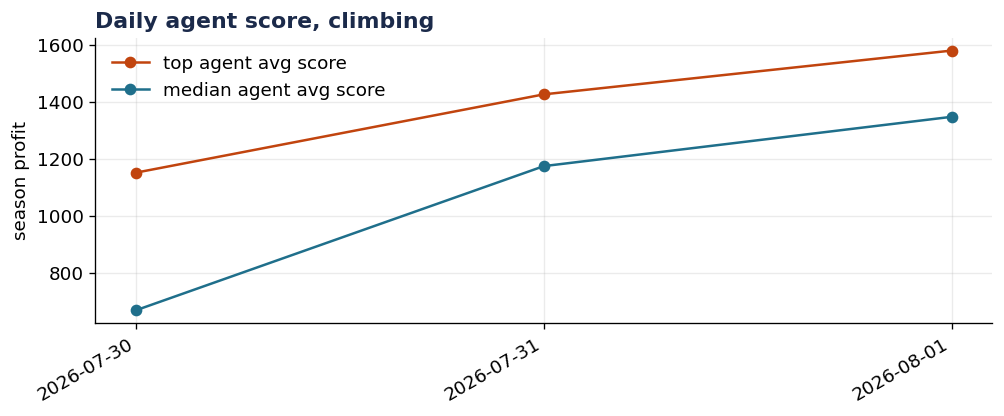

      date  episode_count  top_avg_score  median_avg_score
2026-07-30            864         1152.4             669.8
2026-07-31            928         1427.0            1175.3
2026-08-01            829         1580.6            1348.2


In [6]:
mpath = find_one("manifest.csv")
if mpath:
    man = pd.read_csv(mpath)
    man = man.sort_values("date")
    fig, ax = plt.subplots(figsize=(8.5, 3.6))
    ax.plot(man["date"], man["top_avg_score"], "o-", color=ACC, label="top agent avg score")
    ax.plot(man["date"], man["median_avg_score"], "o-", color=ACC2, label="median agent avg score")
    ax.set_ylabel("season profit"); ax.set_title("Daily agent score, climbing", color=INK, loc="left", fontweight="bold")
    ax.legend(frameon=False); plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()
    print(man[["date", "episode_count", "top_avg_score", "median_avg_score"]].round(1).to_string(index=False))
else:
    print("attach kaggle/kaggriculture-episodes-index to see the daily score trend")

## Honest scope, and how to use it

This is one day of ladder replays, so read it as a snapshot, not a law; fork it onto another day to see what
moves. Each replay is about 25MB, so I read a seeded random sample of at most 300 games of the day, not the
full dump; the parse cell prints exactly how many went in. The winner is the side with the higher final
profit, straight from the replay rewards. Ties and unfinished games are dropped. The strategy counts are the
raw action tallies over the 720 turn season, a faithful count of what each side did, not a judgement of why.
Everything is recomputed from the logs when you run the notebook, with no pasted numbers and no leaderboard
claim, so you can trust it as far as the parse, which is all shown above.

If you want the same live-from-raw-logs read for a different competition, the companion tracker
[What actually wins on the ladder](https://www.kaggle.com/code/busyaprime/what-actually-wins-on-the-ladder)
does this for the Pokemon TCG battle meta, and
[Which open Kaggle competition still has room](https://www.kaggle.com/code/busyaprime/which-open-kaggle-competition-still-has-room)
tracks every open competition worth entering.